In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_csv("student_habits_performance.csv") #initializing dataframe using pandas

In [3]:
df.info() # information about the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [4]:
df.describe() # detailed description of the dataframe

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [5]:
df

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


In [6]:
df.isna().sum() # checking the number of na values in each column

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [10]:
df['parental_education_level'] = df['parental_education_level'].fillna(df['parental_education_level'].mode()[0])
# filling the na values with the mode of the column

In [11]:
df = df.drop("student_id", axis=1)
#dropping "student_id" since its not a feature but an identifier

## Exploratory Data Analysis (EDA)

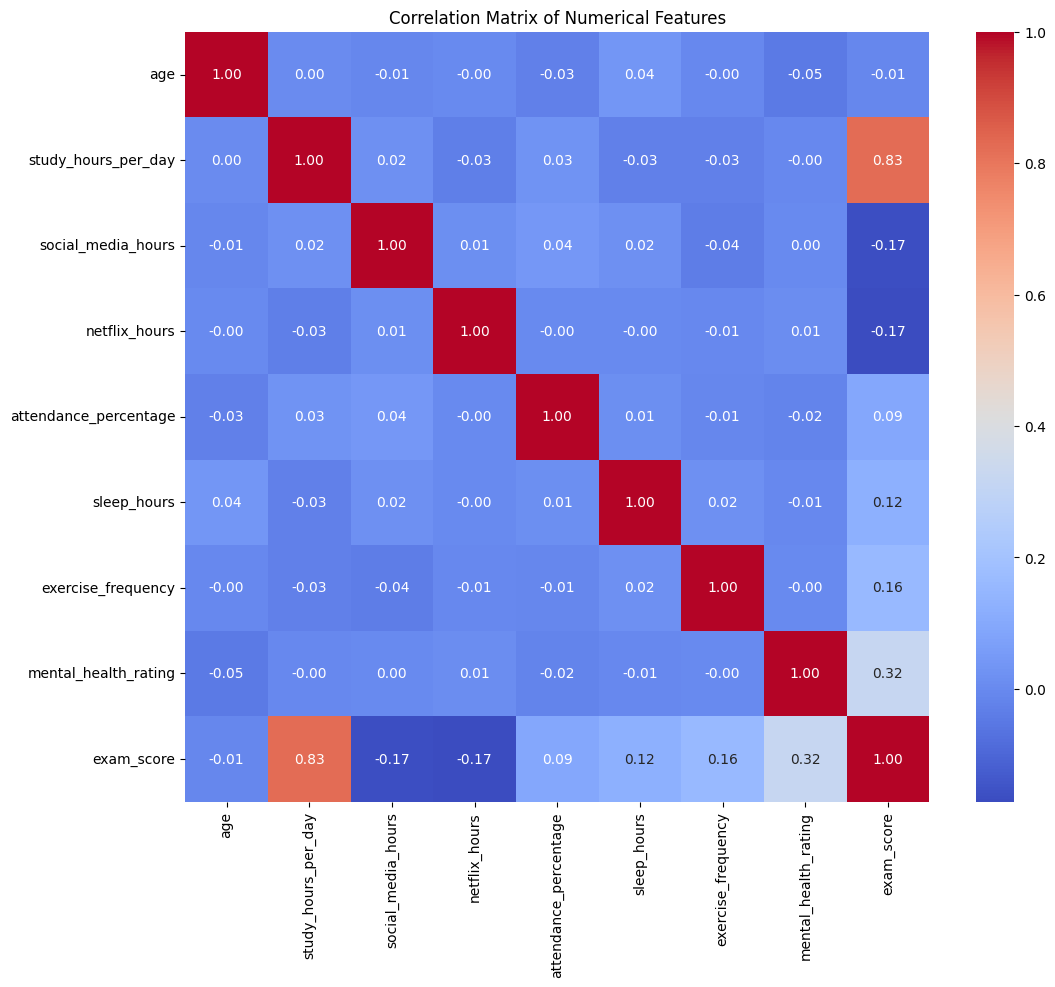

In [12]:
# Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

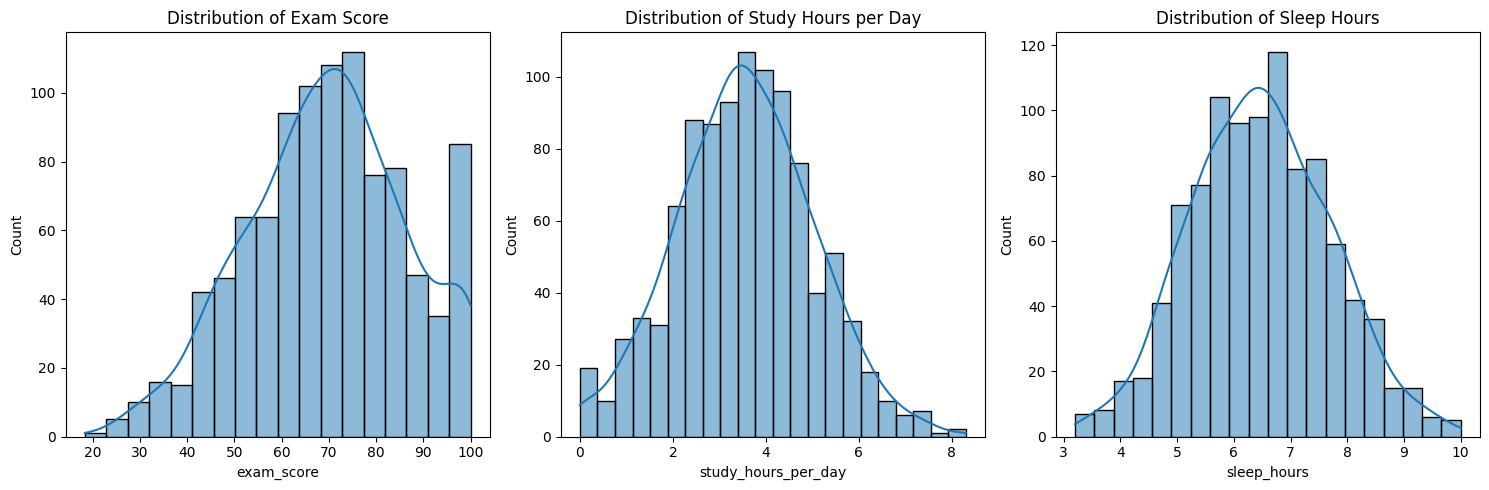

In [13]:
# Distributions of Key Numerical Features

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['exam_score'], kde=True)
plt.title('Distribution of Exam Score')

plt.subplot(1, 3, 2)
sns.histplot(df['study_hours_per_day'], kde=True)
plt.title('Distribution of Study Hours per Day')

plt.subplot(1, 3, 3)
sns.histplot(df['sleep_hours'], kde=True)
plt.title('Distribution of Sleep Hours')

plt.tight_layout()
plt.show()

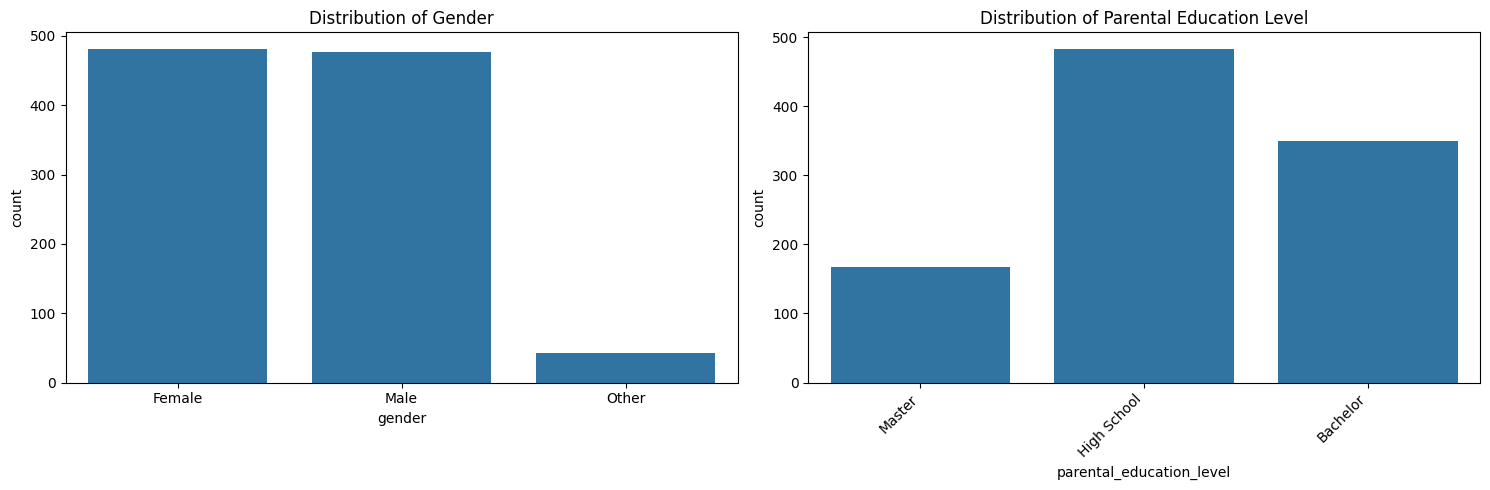

In [14]:
# Distributions of Key Categorical Features

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='gender')
plt.title('Distribution of Gender')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='parental_education_level')
plt.title('Distribution of Parental Education Level')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

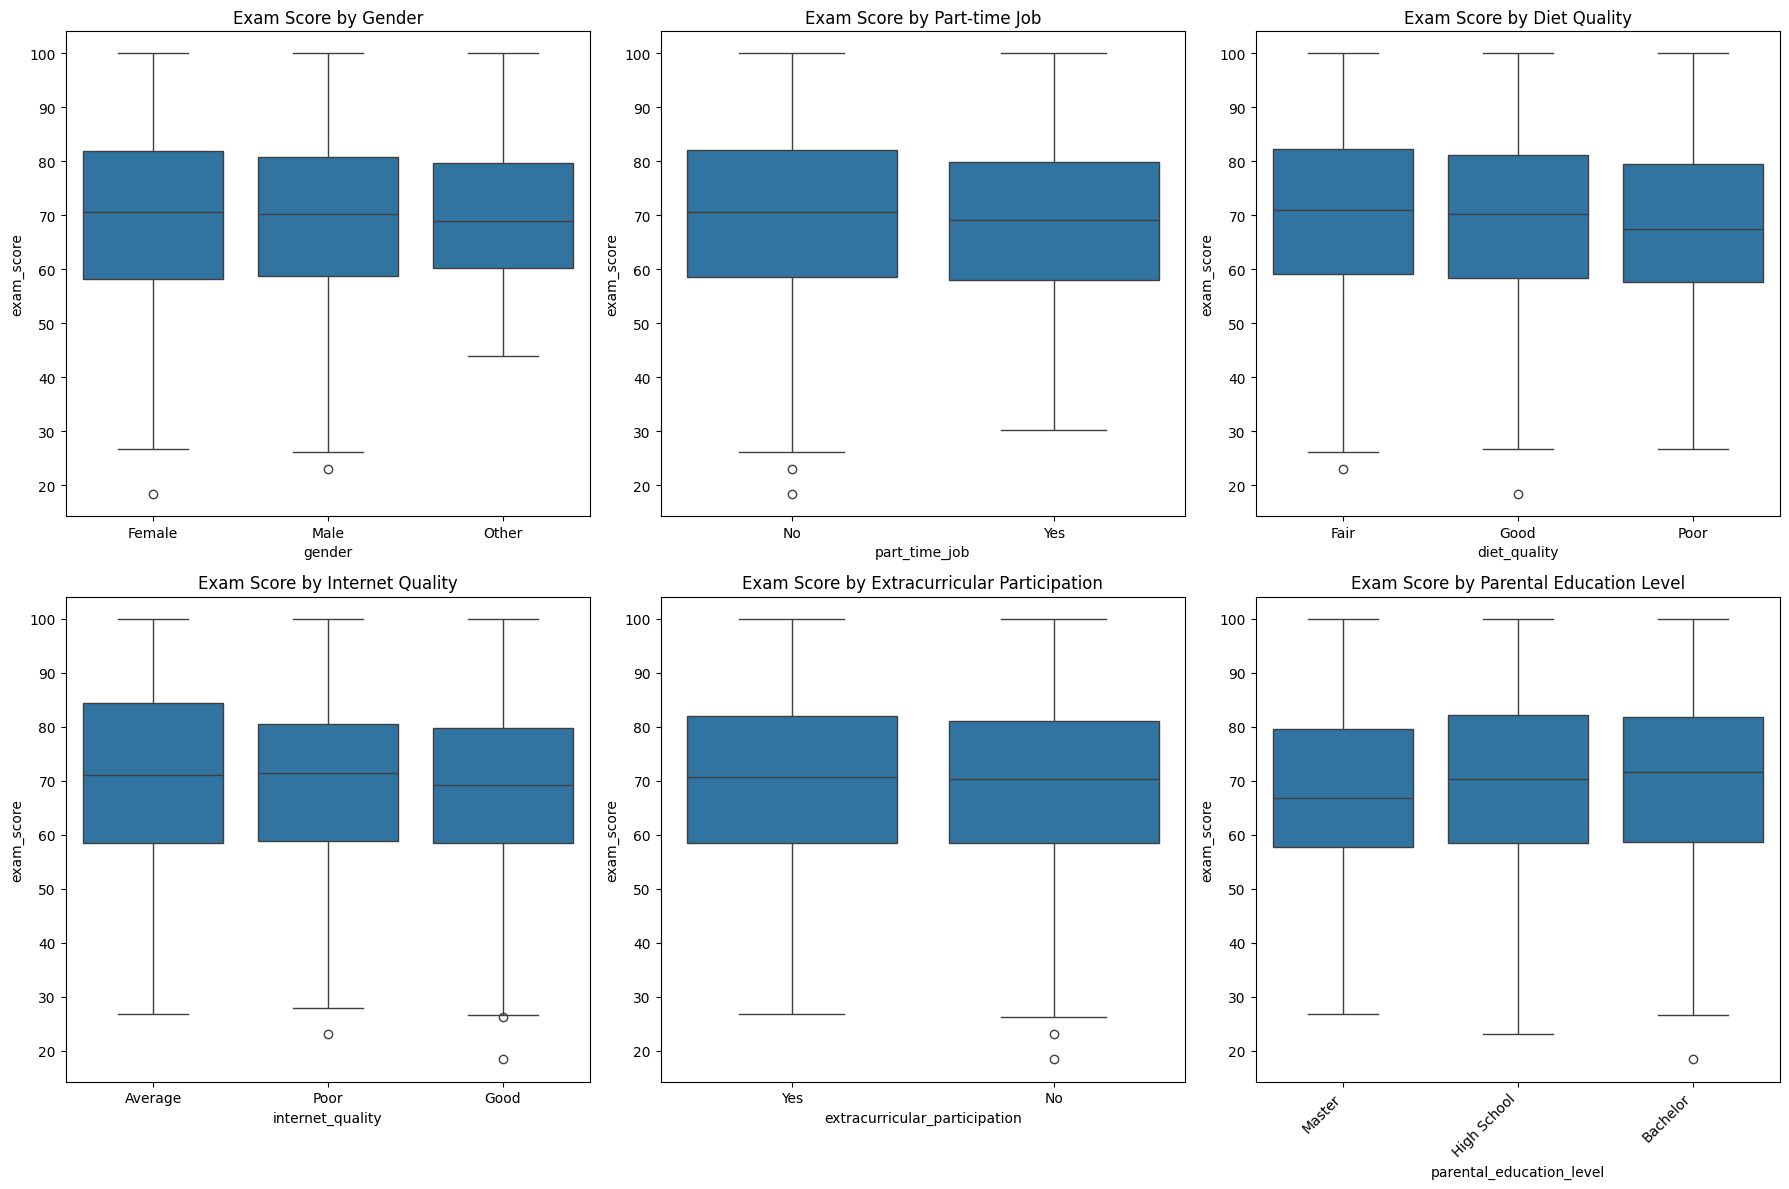

In [15]:
# Exam Score Distribution across Categorical Features

plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
sns.boxplot(data=df, x='gender', y='exam_score')
plt.title('Exam Score by Gender')

plt.subplot(2, 3, 2)
sns.boxplot(data=df, x='part_time_job', y='exam_score')
plt.title('Exam Score by Part-time Job')

plt.subplot(2, 3, 3)
sns.boxplot(data=df, x='diet_quality', y='exam_score')
plt.title('Exam Score by Diet Quality')

plt.subplot(2, 3, 4)
sns.boxplot(data=df, x='internet_quality', y='exam_score')
plt.title('Exam Score by Internet Quality')

plt.subplot(2, 3, 5)
sns.boxplot(data=df, x='extracurricular_participation', y='exam_score')
plt.title('Exam Score by Extracurricular Participation')

plt.subplot(2, 3, 6)
sns.boxplot(data=df, x='parental_education_level', y='exam_score')
plt.title('Exam Score by Parental Education Level')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Linear Regression

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Select only numerical features for X, excluding the target 'exam_score'
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
X = df[numerical_cols].drop('exam_score', axis=1)
y = df['exam_score']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

# Display prediction results (first 5 predictions vs actual)
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nFirst 5 Prediction Results:")
display(predictions_df.head())

# Display model coefficients
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nModel Coefficients:")
display(coefficients)

Mean Absolute Error (MAE): 4.13
Mean Squared Error (MSE): 25.92
Root Mean Squared Error (RMSE): 5.09
R-squared (R2 Score): 0.90

First 5 Prediction Results:


,Actual,Predicted
521,64.2,66.052043
737,72.7,74.481327
740,79.0,78.104848
660,79.5,74.380344
411,58.2,61.424546



Model Coefficients:


,Coefficient
age,0.052559
study_hours_per_day,9.533589
social_media_hours,-2.701878
netflix_hours,-2.316592
attendance_percentage,0.145895
sleep_hours,1.989896
exercise_frequency,1.315593
mental_health_rating,1.952032


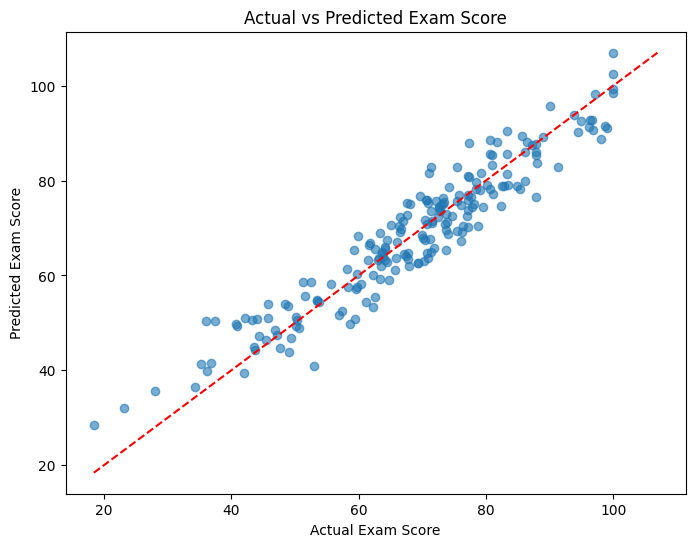

In [22]:
# Actual vs Predicted Exam Score
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Score")

# Reference line: perfect predictions would fall exactly on this diagonal
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--", color="red")

plt.show()